# Main Imports

In [16]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from collections import defaultdict
from matplotlib.ticker import MultipleLocator
import re
import os

# import data
cb_10x = os.path.join("..", "..", "..", "se", "new", "clean-files-ul", "aggr", "agg-cb-10.csv")
cf_10x_aggr = os.path.join("..","..", "..", "se","new","clean-files-ul", "aggr", "agg-cf-10-aggr.csv")
cf_10x = os.path.join("..","..", "..", "se","new","clean-files-ul", "aggr", "agg-cf-10.csv")
cb_5x = os.path.join("..","..", "..", "se","new","clean-files-ul", "aggr", "agg-cb-5.csv")
cf_5x_aggr = os.path.join("..","..", "..", "se","new","clean-files-ul", "aggr", "agg-cf-5-aggr.csv")
cf_5x = os.path.join("..","..", "..", "se","new","clean-files-ul", "aggr", "agg-cf-5.csv")
cf_1x_aggr = os.path.join("..","..", "..", "se","new","clean-files-ul", "aggr", "agg-cf-1-agg.csv")
cb_1x = os.path.join("..","..", "..", "se","new","clean-files-ul", "aggr", "agg-cb-1.csv")
cf_1x = os.path.join("..","..", "..", "se","new","clean-files-ul", "aggr", "agg-cf-1.csv")

# Calculations for every file

#### 1x Scenarios

In [17]:
# Read content of the file
df_cb_1 = pd.read_csv(cb_1x)
df_cf_1 = pd.read_csv(cf_1x)
df_cf_1_aggr = pd.read_csv(cf_1x_aggr)

In [ ]:
def read_data_by_ue(csv_path): 
  df = pd.read_csv(csv_path)

  dfs = {}

  for ue_id, group in df.groupby("UE_ID"):
    df_ue = group.sort_values("Time_ms").reset_index(drop=True)
    df_ue["Rolling Avg (bit/s/Hz)"] = df_ue["Mean_UL_SE_bit_per_s_Hz"].rolling(window=5, min_periods=1).mean()
    dfs[ue_id] = df_ue
  
  return dfs

dfs_cb_1 = read_data_by_ue(cb_1x)
dfs_cf_1 = read_data_by_ue(cf_1x)
df_cf_1_aggr = read_data_by_ue(cf_1x_aggr)



print(df_cf_1)

{'UE0':      Time_ms UE_ID  SNR_total_linear  Mean_UL_SE_bit_per_s_Hz  \
0          0   UE0      6.312586e+08                27.771973   
1        100   UE0      1.138160e+09                28.579854   
2        200   UE0      1.209294e+09                28.662942   
3        300   UE0      1.138974e+09                28.580833   
4        400   UE0      1.232882e+09                28.689418   
..       ...   ...               ...                      ...   
896    89600   UE0      1.184883e+09                28.634993   
897    89700   UE0      1.161775e+09                28.607999   
898    89800   UE0      1.194055e+09                28.645561   
899    89900   UE0      1.160452e+09                28.606438   
900    90000   UE0      5.723202e+08                27.637635   

     Rolling Avg (bit/s/Hz)  
0                 27.771973  
1                 28.175913  
2                 28.338256  
3                 28.398900  
4                 28.457004  
..                      ...  
8

#### 5x Scenarios

In [48]:
def read_data_by_ue(csv_path): 
  df = pd.read_csv(csv_path)

  dfs = {}

  for ue_id, group in df.groupby("UE_ID"):
    df_ue = group.sort_values("Time_ms").reset_index(drop=True)
    df_ue["Rolling Avg (bit/s/Hz)"] = df_ue["Mean_UL_SE_bit_per_s_Hz"].rolling(window=5, min_periods=1).mean()
    dfs[ue_id] = df_ue
  
  return dfs

dfs_cb_5 = read_data_by_ue(cb_5x)
dfs_cf_5 = read_data_by_ue(cf_5x)

def read_data_by_ue_2(csv_path): 
  df = pd.read_csv(csv_path)

  dfs = {}

  for ue_id, group in df.groupby("UE"):
    df_ue = group.sort_values("Time_ms").reset_index(drop=True)
    df_ue["Rolling Avg (bit/s/Hz)"] = df_ue["SE_total_bit_per_s_Hz"].rolling(window=5, min_periods=1).mean()
    dfs[ue_id] = df_ue
  
  return dfs

dfs_cf_5_aggr = read_data_by_ue_2(cf_5x_aggr)

FileNotFoundError: [Errno 2] No such file or directory: '..\\..\\..\\se\\new\\clean-files-ul\\aggr\\agg-cf-5-aggr.csv'

#### 10x Scenarios

In [47]:
def read_data_by_ue(csv_path): 
  df = pd.read_csv(csv_path)

  dfs = {}

  for ue_id, group in df.groupby("UE_ID"):
    df_ue = group.sort_values("Time_ms").reset_index(drop=True)
    df_ue["Rolling Avg (bit/s/Hz)"] = df_ue["Mean_UL_SE_bit_per_s_Hz"].rolling(window=5, min_periods=1).mean()
    dfs[ue_id] = df_ue
  
  return dfs

dfs_cb_10 = read_data_by_ue(cb_10x)
dfs_cf_10 = read_data_by_ue(cf_10x)
dfs_cf_10_aggr = read_data_by_ue(cf_10x_aggr)

KeyError: 'UE_ID'

# Behavior Graphics 

## 1X Scenarios

In [62]:
df_cb_1["Mean_UL_SE_bit_per_s_Hz"] = df_cb_1["Mean_UL_SE_bit_per_s_Hz"].round(3)
df_cb_1["Rolling Avg (bit/s/Hz)"] = df_cb_1["Mean_UL_SE_bit_per_s_Hz"].rolling(window=5).mean()

df_cf_1["Mean_UL_SE_bit_per_s_Hz"] = df_cf_1["Mean_UL_SE_bit_per_s_Hz"].round(3)
df_cf_1["Rolling Avg (bit/s/Hz)"] = df_cf_1["Mean_UL_SE_bit_per_s_Hz"].rolling(window=5).mean()

df_cf_1_aggr["Mean_UL_SE_bit_per_s_Hz"] = df_cf_1_aggr["Mean_UL_SE_bit_per_s_Hz"].round(3)
df_cf_1_aggr["Rolling Avg (bit/s/Hz)"] = df_cf_1_aggr["Mean_UL_SE_bit_per_s_Hz"].rolling(window=5).mean()

plt.figure(figsize=(14, 6))
sns.lineplot(x="Time_ms", y="Mean_UL_SE_bit_per_s_Hz", data=df_cb_1, label="Mean SE Uplink(bit/s/Hz) CB")
sns.lineplot(x="Time_ms", y="Rolling Avg (bit/s/Hz)", data=df_cb_1, label="Rolling Avg CB")
sns.lineplot(x="Time_ms", y="Mean_UL_SE_bit_per_s_Hz", data=df_cf_1, label="Mean SE Uplink (bit/s/Hz) CF")
sns.lineplot(x="Time_ms", y="Rolling Avg (bit/s/Hz)", data=df_cf_1, label="Rolling Avg CF")
sns.lineplot(x="Time_ms", y="Mean_UL_SE_bit_per_s_Hz", data=df_cf_1, label="Mean SE Uplink (bit/s/Hz) CF AGGR")
sns.lineplot(x="Time_ms", y="Rolling Avg (bit/s/Hz)", data=df_cf_1, label="Rolling Avg CF AGGR")
plt.title("Mean SE in time for Uplink\n(Cell Based 1x UE)")
plt.xlabel("Time (ms)")
plt.ylabel("SE Uplink(bit/s/Hz)")
plt.legend()
plt.ylim(0, 30)
plt.xlim(left=0)
plt.gca().xaxis.set_major_locator(MultipleLocator(5000))
plt.grid(True, linestyle='--', alpha=0.7)
plt.tight_layout()
plt.show()

KeyError: 'Mean_UL_SE_bit_per_s_Hz'

In [ ]:
print(df_cb_1["Mean_UL_SE_bit_per_s_Hz"].describe())
print(df_cf_1["Mean_UL_SE_bit_per_s_Hz"].describe())
print(df_cf_1_aggr["Mean_UL_SE_bit_per_s_Hz"].describe())

count    994.000000
mean      20.753109
std        0.247941
min       17.342000
25%       20.778000
50%       20.778000
75%       20.778000
max       20.778000
Name: Mean_UL_SE_bit_per_s_Hz, dtype: float64
count    1802.000000
mean       20.521447
std         0.139151
min        20.211000
25%        20.417000
50%        20.530000
75%        20.654000
max        20.778000
Name: Mean_UL_SE_bit_per_s_Hz, dtype: float64


KeyError: 'Mean_UL_SE_bit_per_s_Hz'

In [55]:
heat_cb = df_cb_1.pivot(index="UE_ID", columns="Time_ms", values="Mean_UL_SE_bit_per_s_Hz")
heat_cf = df_cf_1.pivot(index="UE_ID", columns="Time_ms", values="Mean_UL_SE_bit_per_s_Hz")
heat_cf_aggr = df_cf_1_aggr.pivot(index="UE_ID", columns="Time_ms", values="Mean_UL_SE_bit_per_s_Hz")

# Plot Cell-Based
plt.figure(figsize=(14, 6))
sns.heatmap(heat_cb, cmap="viridis", cbar_kws={'label': 'Mean SE (bit/s/Hz) Uplink'})
plt.title("SE Uplink Heatmap by UE & Time (Cell-Based 1x UE)")
plt.xlabel("Time (ms)")
plt.locator_params(axis="x", nbins=20)
plt.ylabel("UE")
plt.tight_layout()
plt.xlim(0,500)
plt.show()

# Plot Cell-Free
plt.figure(figsize=(14, 6))
sns.heatmap(heat_cf, cmap="viridis", cbar_kws={'label': 'Mean SE (bit/s/Hz) Uplink'})
plt.title("SE Uplink Heatmap by UE & Time (Cell-Free 1x UE)")
plt.xlabel("Time (ms)")
plt.locator_params(axis="x", nbins=20)
plt.ylabel("UE")
plt.xlim(0,500)
plt.tight_layout()
plt.show()

# Plot Cell-Free
plt.figure(figsize=(14, 6))
sns.heatmap(heat_cf, cmap="viridis", cbar_kws={'label': 'Mean SE (bit/s/Hz) Uplink'})
plt.title("SE Uplink Heatmap by UE & Time (Cell-Free 1x UE Aggregated)")
plt.xlabel("Time (ms)")
plt.locator_params(axis="x", nbins=20)
plt.ylabel("UE")
plt.xlim(0,500)
plt.tight_layout()
plt.show()

AttributeError: 'dict' object has no attribute 'pivot'

## 5X Scenarios

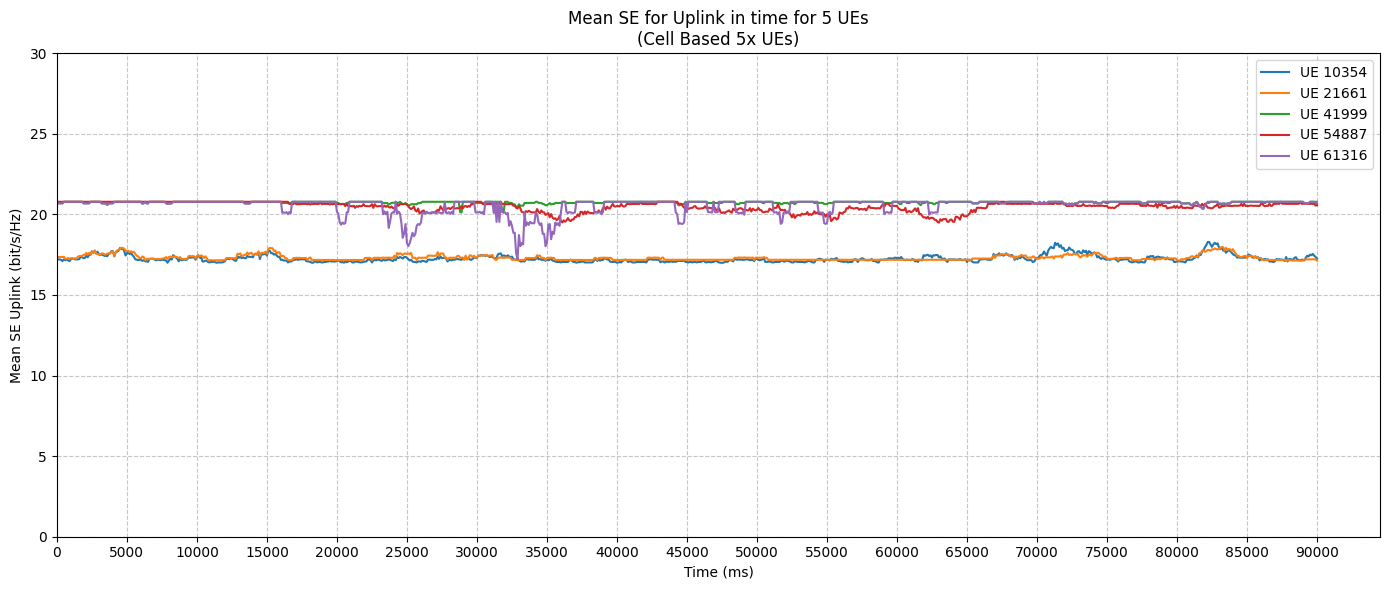

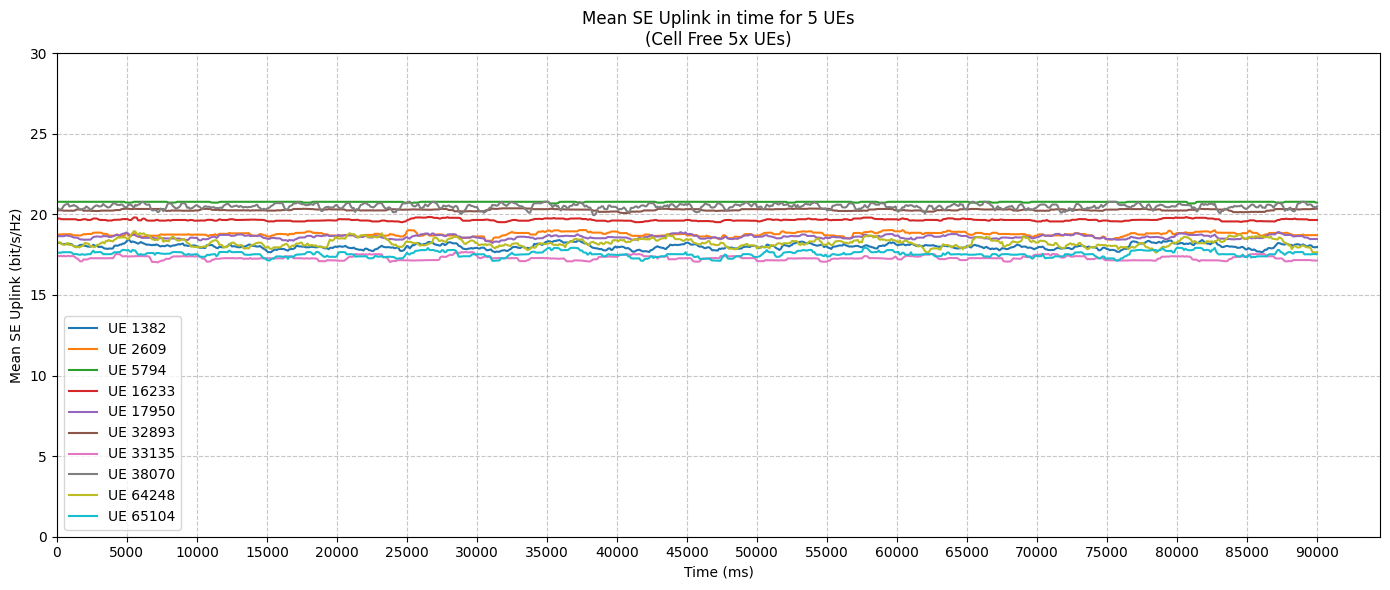

In [10]:
plt.figure(figsize=(14, 6))

# Graphic of Throughput and Rolling Average
for ue, df in dfs_cb_5.items():
    dfs_cb_5[ue]["Mean_UL_SE_bit_per_s_Hz"] = dfs_cb_5[ue]["Mean_UL_SE_bit_per_s_Hz"].round(3)

    sns.lineplot(x="Time_ms", y="Mean_UL_SE_bit_per_s_Hz", data=df, label=f"UE {ue}")

plt.title("Mean SE for Uplink in time for 5 UEs\n(Cell Based 5x UEs)")
plt.xlabel("Time (ms)")
plt.ylabel("Mean SE Uplink (bit/s/Hz)")
plt.grid(True)
plt.legend()

plt.ylim(0, 30)
plt.xlim(left=0)
plt.gca().xaxis.set_major_locator(MultipleLocator(5000))
plt.grid(True, linestyle='--', alpha=0.7)
plt.tight_layout()
plt.show()


plt.figure(figsize=(14, 6))

# Graphic of Throughput and Rolling Average
for ue, df in dfs_cf_5.items():
    dfs_cf_5[ue]["Mean_UL_SE_bit_per_s_Hz"] = dfs_cf_5[ue]["Mean_UL_SE_bit_per_s_Hz"].round(3)

    sns.lineplot(x="Time_ms", y="Mean_UL_SE_bit_per_s_Hz", data=df, label=f"UE {ue}")

plt.title("Mean SE Uplink in time for 5 UEs\n(Cell Free 5x UEs)")
plt.xlabel("Time (ms)")
plt.ylabel("Mean SE Uplink (bit/s/Hz)")
plt.grid(True)
plt.legend()

plt.ylim(0, 30)
plt.xlim(left=0)
plt.gca().xaxis.set_major_locator(MultipleLocator(5000))
plt.grid(True, linestyle='--', alpha=0.7)
plt.tight_layout()
plt.show()



In [11]:
df_cb_5 = pd.read_csv(cb_5x)
df_cf_5 = pd.read_csv(cf_5x)

print(df_cb_5["Mean_UL_SE_bit_per_s_Hz"].describe())
print(df_cf_5["Mean_UL_SE_bit_per_s_Hz"].describe())

count    4505.000000
mean       19.261556
std         1.648777
min        16.993652
25%        17.288000
50%        20.374821
75%        20.778000
max        20.778000
Name: Mean_UL_SE_bit_per_s_Hz, dtype: float64
count    9010.000000
mean       18.962984
std         1.202020
min        17.014731
25%        17.962931
50%        18.690241
75%        20.259495
max        20.778000
Name: Mean_UL_SE_bit_per_s_Hz, dtype: float64


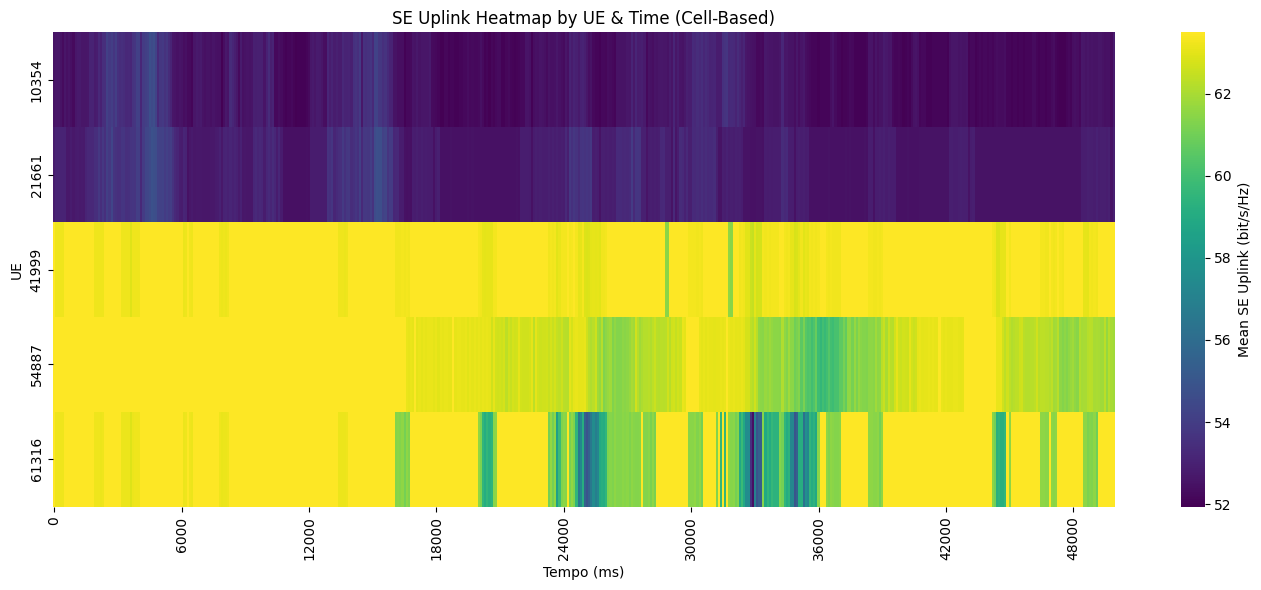

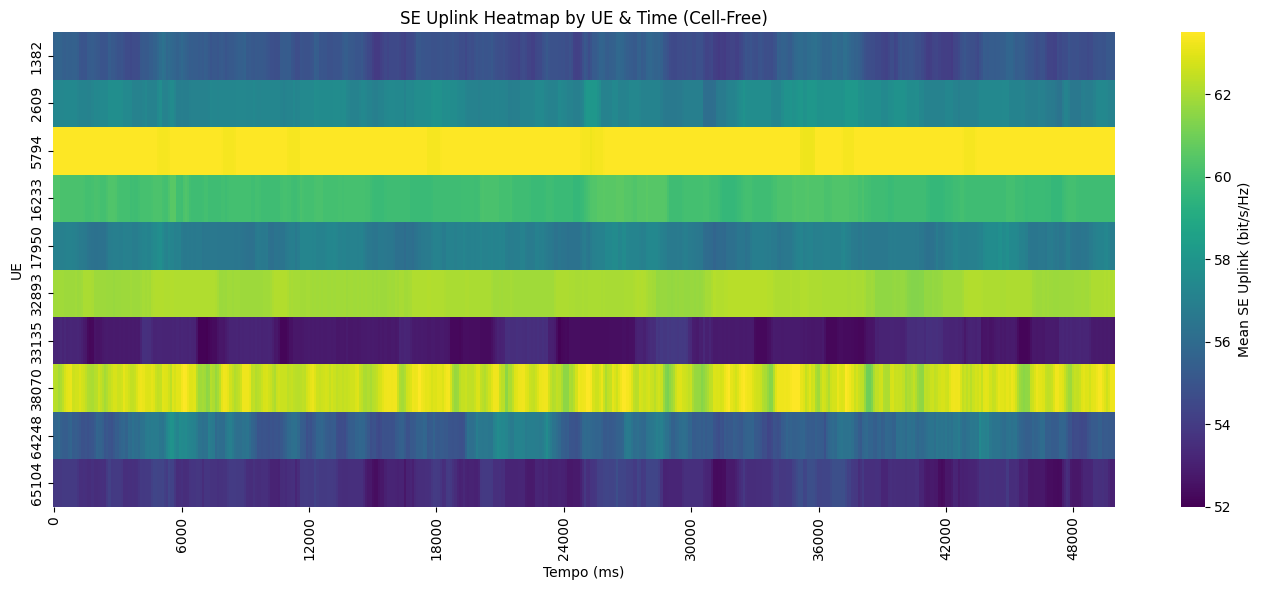

In [15]:
heat_cb = df_cb_5.pivot(index="UE_ID", columns="Time_ms", values="Mean_SE")
heat_cf = df_cf_5.pivot(index="UE_ID", columns="Time_ms", values="Mean_SE")

# Plot Cell-Based
plt.figure(figsize=(14, 6))
sns.heatmap(heat_cb, cmap="viridis", cbar_kws={'label': 'Mean SE Uplink (bit/s/Hz)'})
plt.title("SE Uplink Heatmap by UE & Time (Cell-Based)")
plt.xlabel("Tempo (ms)")
plt.locator_params(axis="x", nbins=20)
plt.ylabel("UE")
plt.tight_layout()
plt.xlim(0,500)
plt.show()

# Plot Cell-Free
plt.figure(figsize=(14, 6))
sns.heatmap(heat_cf, cmap="viridis", cbar_kws={'label': 'Mean SE Uplink (bit/s/Hz)'})
plt.title("SE Uplink Heatmap by UE & Time (Cell-Free)")
plt.xlabel("Tempo (ms)")
plt.locator_params(axis="x", nbins=20)
plt.ylabel("UE")
plt.xlim(0,500)
plt.tight_layout()
plt.show()

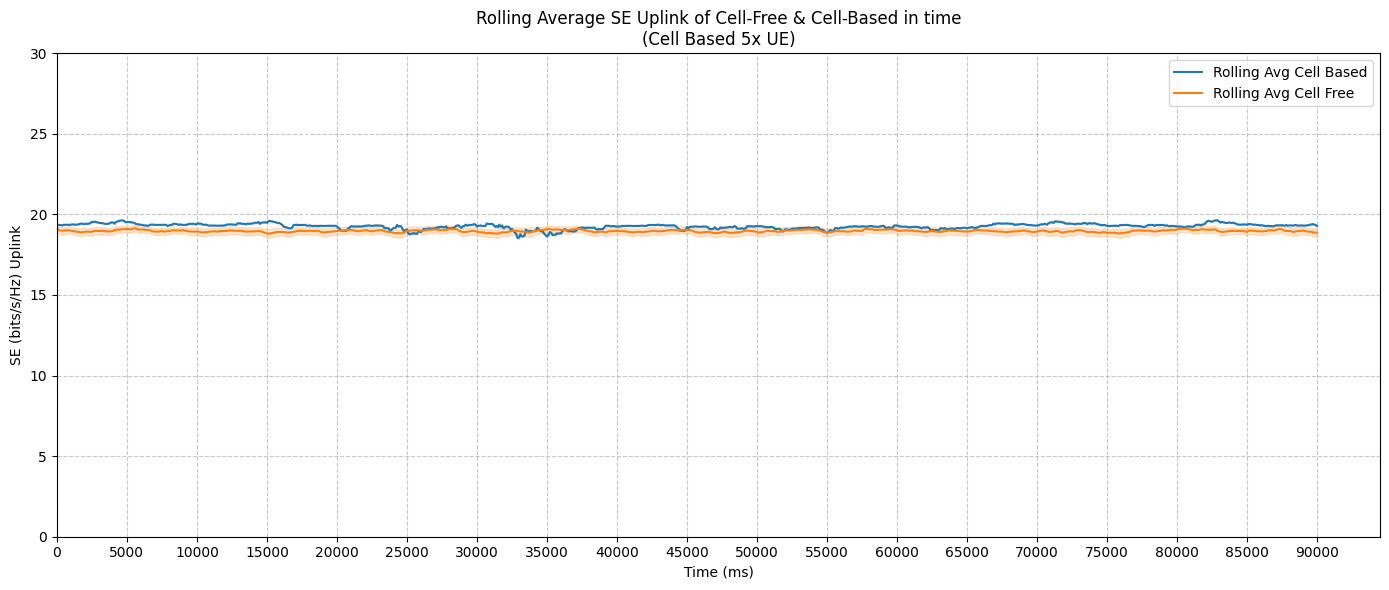

In [13]:
# Round of throughput values to 3 decimal places
df_cb_5["Mean_UL_SE_bit_per_s_Hz"] = df_cb_5["Mean_UL_SE_bit_per_s_Hz"].round(3)
# Calculate rolling average with a window of 5
df_cb_5["Rolling Avg (bits/s/Hz)"] = df_cb_5["Mean_UL_SE_bit_per_s_Hz"].rolling(window=5).mean()

# Round of throughput values to 3 decimal places
df_cf_5["Mean_UL_SE_bit_per_s_Hz"] = df_cf_5["Mean_UL_SE_bit_per_s_Hz"].round(3)
# Calculate rolling average with a window of 5
df_cf_5["Rolling Avg (bits/s/Hz)"] = df_cf_5["Mean_UL_SE_bit_per_s_Hz"].rolling(window=5).mean()

# Graphic of Throughput and Rolling Average
plt.figure(figsize=(14, 6))
sns.lineplot(x="Time_ms", y="Rolling Avg (bits/s/Hz)", data=df_cb_5, label="Rolling Avg Cell Based")
sns.lineplot(x="Time_ms", y="Rolling Avg (bits/s/Hz)", data=df_cf_5, label="Rolling Avg Cell Free")
plt.title("Rolling Average SE Uplink of Cell-Free & Cell-Based in time\n(Cell Based 5x UE)")
plt.xlabel("Time (ms)")
plt.ylabel("SE (bits/s/Hz) Uplink")
plt.legend()

plt.grid(True)
plt.ylim(0, 30)
plt.xlim(left=0)
plt.gca().xaxis.set_major_locator(MultipleLocator(5000))
plt.grid(True, linestyle='--', alpha=0.7)
plt.tight_layout()
plt.show()

## 10X Scenarios

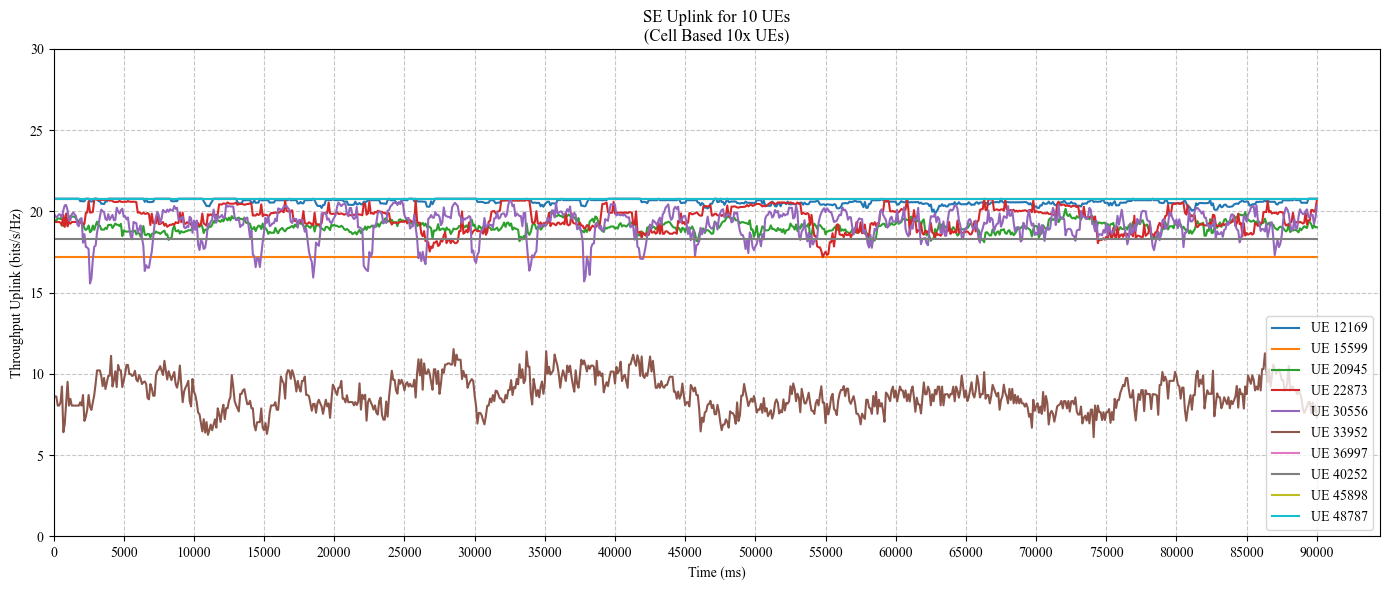

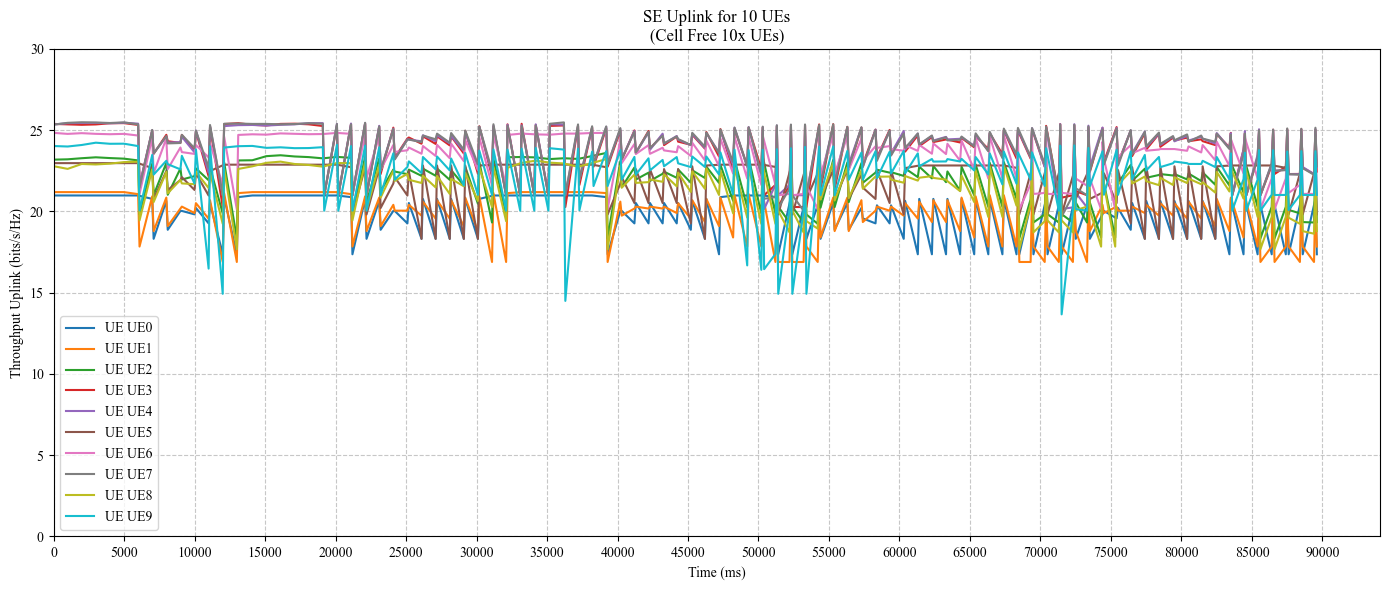

In [46]:
# Graphic of Throughput and Rolling Average
plt.figure(figsize=(14, 6))
for ue, df in dfs_cb_10.items():
    sns.lineplot(x="Time_ms", y="Mean_UL_SE_bit_per_s_Hz", data=df, label=f"UE {ue}")
plt.title("SE Uplink for 10 UEs\n(Cell Based 10x UEs)")
plt.xlabel("Time (ms)")
plt.ylabel("Throughput Uplink (bits/s/Hz)")
plt.grid(True)
plt.legend()

plt.ylim(0, 30)
plt.xlim(left=0)
plt.gca().xaxis.set_major_locator(MultipleLocator(5000))
plt.grid(True, linestyle='--', alpha=0.7)
plt.tight_layout()
plt.show()


# Graphic of Throughput and Rolling Average
plt.figure(figsize=(14, 6))
#for ue, df in dfs_cf_10.items():
#    sns.lineplot(x="Time_ms", y="Mean_UL_SE_bit_per_s_Hz", data=df, label=f"UE {ue}")
for ue, df in dfs_cf_10_aggr.items():
    sns.lineplot(x="Time_ms", y="SE_total_bit_per_s_Hz", data=df, label=f"UE {ue}")
plt.title("SE Uplink for 10 UEs\n(Cell Free 10x UEs)")
plt.xlabel("Time (ms)")
plt.ylabel("Throughput Uplink (bits/s/Hz)")
plt.grid(True)
plt.legend()

plt.ylim(0, 30)
plt.xlim(left=0)
plt.gca().xaxis.set_major_locator(MultipleLocator(5000))
plt.grid(True, linestyle='--', alpha=0.7)
plt.tight_layout()
plt.show()

In [69]:
df_cb_10 = pd.read_csv(cb_10x)
df_cf_10 = pd.read_csv(cf_10x)
dfs_cf_10_aggr = pd.read_csv(cf_10x_aggr)

print(df_cb_10["Mean_UL_SE_bit_per_s_Hz"].describe())
print(df_cf_10["Mean_UL_SE_bit_per_s_Hz"].describe())
print(dfs_cf_10_aggr["SE_total_bit_per_s_Hz"].describe())

count    9010.000000
mean       18.498316
std         3.476139
min         6.108520
25%        18.324000
50%        19.567956
75%        20.778000
max        20.778000
Name: Mean_UL_SE_bit_per_s_Hz, dtype: float64
count    3830.000000
mean       17.551168
std         4.138021
min         2.549000
25%        17.506000
50%        18.487000
75%        20.101366
max        20.778000
Name: Mean_UL_SE_bit_per_s_Hz, dtype: float64
count    1736.000000
mean       22.206233
std         2.170868
min        13.661690
25%        20.766790
50%        22.553721
75%        23.935566
max        25.476397
Name: SE_total_bit_per_s_Hz, dtype: float64


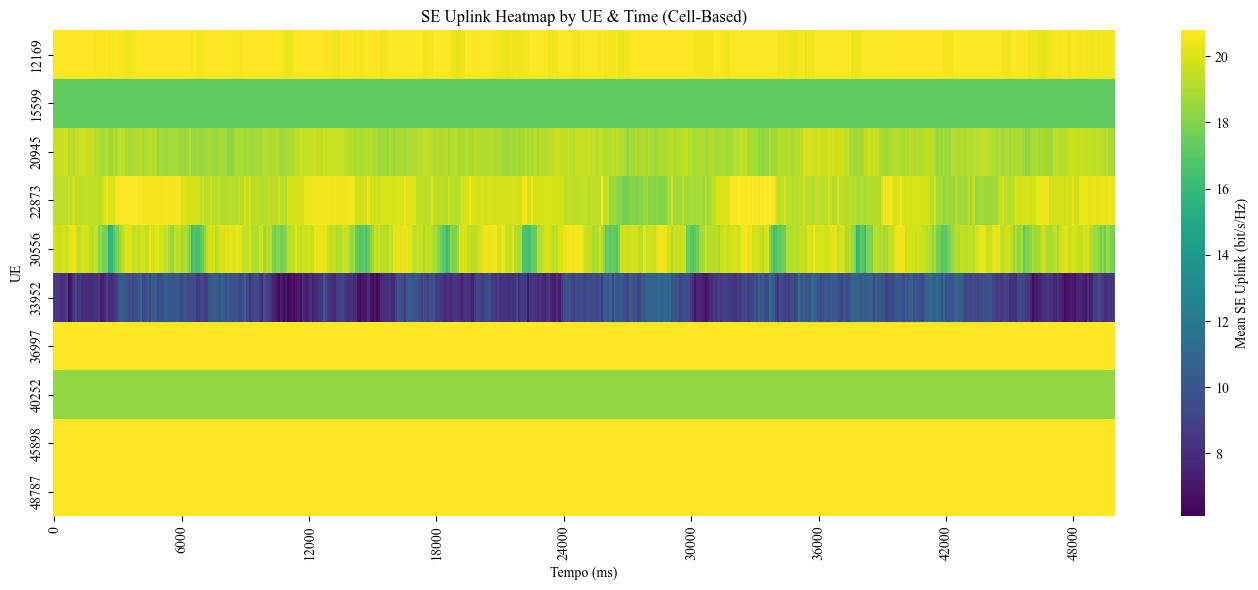

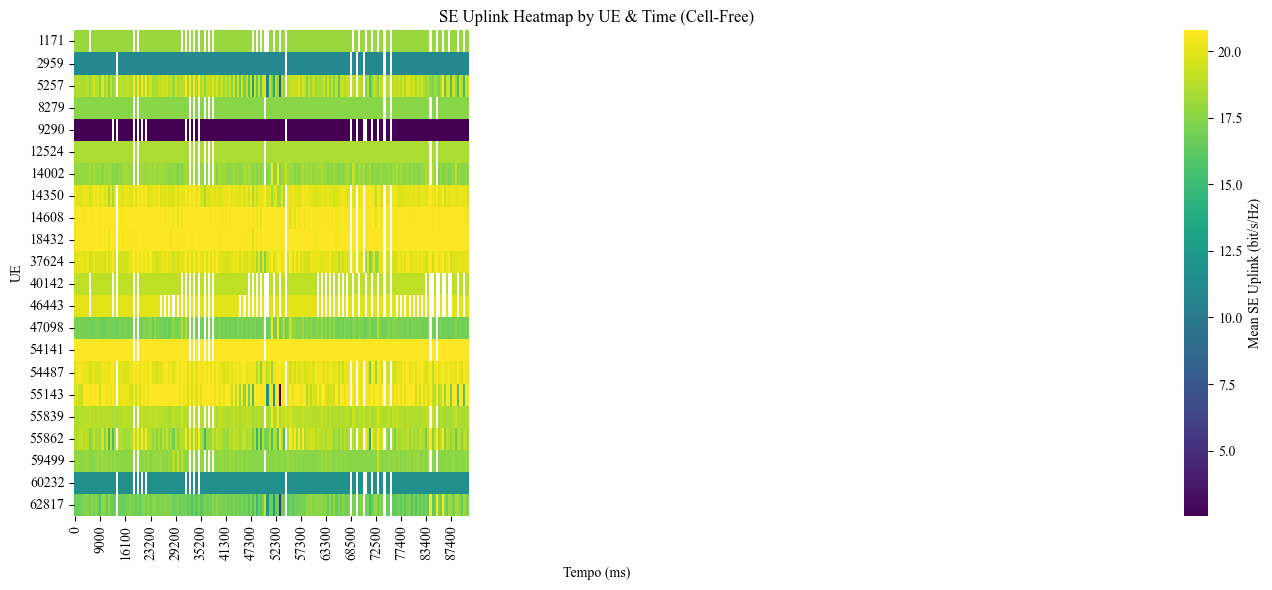

In [58]:

heat_cb = df_cb_10.pivot(index="UE_ID", columns="Time_ms", values="Mean_UL_SE_bit_per_s_Hz")
heat_cf = df_cf_10.pivot(index="UE_ID", columns="Time_ms", values="Mean_UL_SE_bit_per_s_Hz")

# Plot Cell-Based
plt.figure(figsize=(14, 6))
sns.heatmap(heat_cb, cmap="viridis", cbar_kws={'label': 'Mean SE Uplink (bit/s/Hz)'})
plt.title("SE Uplink Heatmap by UE & Time (Cell-Based)")
plt.xlabel("Tempo (ms)")
plt.locator_params(axis="x", nbins=20)
plt.ylabel("UE")
plt.tight_layout()
plt.xlim(0,500)
plt.show()

# Plot Cell-Free
plt.figure(figsize=(14, 6))
sns.heatmap(heat_cf, cmap="viridis", cbar_kws={'label': 'Mean SE Uplink (bit/s/Hz)'})
plt.title("SE Uplink Heatmap by UE & Time (Cell-Free)")
plt.xlabel("Tempo (ms)")
plt.locator_params(axis="x", nbins=20)
plt.ylabel("UE")
plt.xlim(0,500)
plt.tight_layout()
plt.show()


In [ ]:
# Round of throughput values to 3 decimal places
df_cb_10["Mean_UL_SE_bit_per_s_Hz"] = df_cb_10["Mean_UL_SE_bit_per_s_Hz"].round(3)
# Calculate rolling average with a window of 5
df_cb_10["Rolling Avg (bits/s/Hz)"] = df_cb_10["Mean_UL_SE_bit_per_s_Hz"].rolling(window=5).mean()

# Round of throughput values to 3 decimal places
df_cf_10["Mean_UL_SE_bit_per_s_Hz"] = df_cf_10["Mean_UL_SE_bit_per_s_Hz"].round(3)
# Calculate rolling average with a window of 5
df_cf_10["Rolling Avg (bits/s/Hz)"] = df_cf_10["Mean_UL_SE_bit_per_s_Hz"].rolling(window=5).mean()

# Round of throughput values to 3 decimal places
dfs_cf_10_aggr["SE_total_bit_per_s_Hz"] = dfs_cf_10_aggr["SE_total_bit_per_s_Hz"].round(3)
# Calculate rolling average with a window of 5
dfs_cf_10_aggr["Rolling Avg (bits/s/Hz)"] = dfs_cf_10_aggr["SE_total_bit_per_s_Hz"].rolling(window=5).mean()

# Graphic of Throughput and Rolling Average
plt.figure(figsize=(14, 6))
sns.lineplot(x="Time_ms", y="Rolling Avg (bits/s/Hz)", data=df_cb_10, label="Rolling Avg Cell Based")
sns.lineplot(x="Time_ms", y="Rolling Avg (bits/s/Hz)", data=df_cf_10, label="Rolling Avg Cell Free")
sns.lineplot(x="Time_ms", y="Rolling Avg (bits/s/Hz)", data=dfs_cf_10_aggr, label="Rolling Avg Cell Free")
plt.title("Rolling Average SE Uplink of Cell-Free & Cell-Based in time\n(10x UE)")
plt.xlabel("Time (ms)")
plt.ylabel("SE Uplink (bits/s/Hz)")
plt.legend()

plt.grid(True)
plt.ylim(0, 30)
plt.xlim(left=0)
plt.gca().xaxis.set_major_locator(MultipleLocator(5000))
plt.grid(True, linestyle='--', alpha=0.7)
plt.tight_layout()
plt.show()

KeyError: 'SE_total_bit_per_s_Hz'

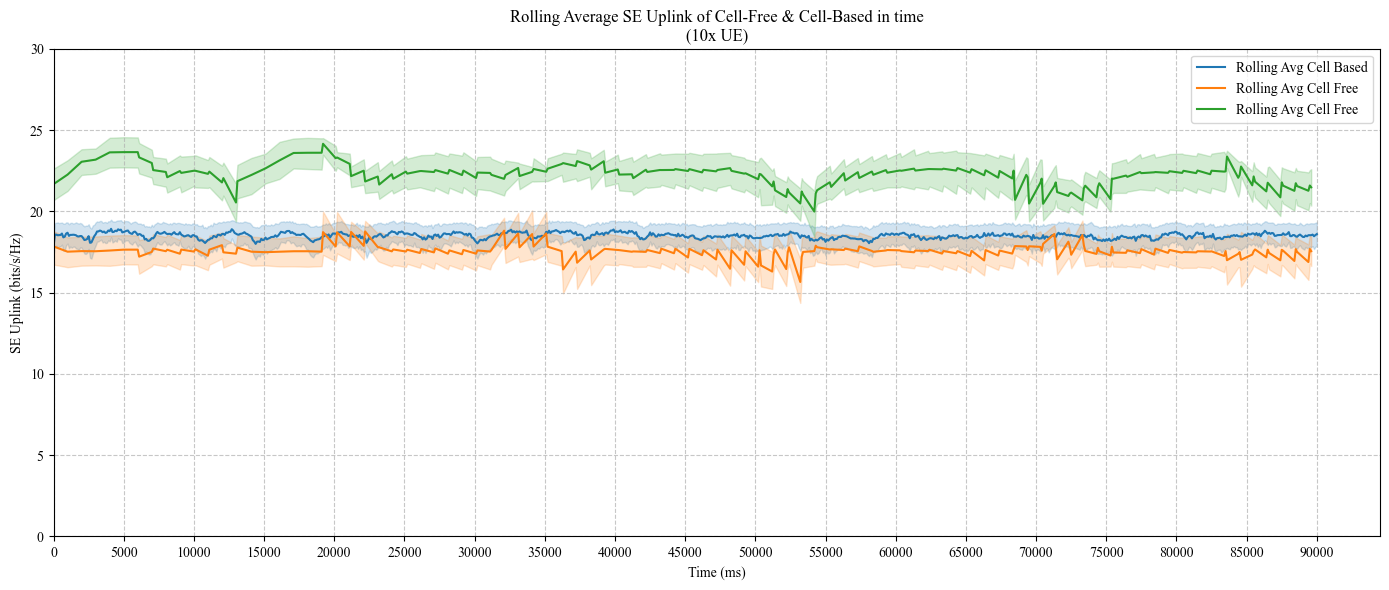

In [70]:
# Round of throughput values to 3 decimal places
df_cb_10["Mean_UL_SE_bit_per_s_Hz"] = df_cb_10["Mean_UL_SE_bit_per_s_Hz"].round(3)
# Calculate rolling average with a window of 5
df_cb_10["Rolling Avg (bits/s/Hz)"] = df_cb_10["Mean_UL_SE_bit_per_s_Hz"].rolling(window=5).mean()

# Round of throughput values to 3 decimal places
df_cf_10["Mean_UL_SE_bit_per_s_Hz"] = df_cf_10["Mean_UL_SE_bit_per_s_Hz"].round(3)
# Calculate rolling average with a window of 5
df_cf_10["Rolling Avg (bits/s/Hz)"] = df_cf_10["Mean_UL_SE_bit_per_s_Hz"].rolling(window=5).mean()

# Round of throughput values to 3 decimal places
dfs_cf_10_aggr["SE_total_bit_per_s_Hz"] = dfs_cf_10_aggr["SE_total_bit_per_s_Hz"].round(3)
# Calculate rolling average with a window of 5
dfs_cf_10_aggr["Rolling Avg (bits/s/Hz)"] = dfs_cf_10_aggr["SE_total_bit_per_s_Hz"].rolling(window=5).mean()

# Graphic of Throughput and Rolling Average
plt.figure(figsize=(14, 6))
sns.lineplot(x="Time_ms", y="Rolling Avg (bits/s/Hz)", data=df_cb_10, label="Rolling Avg Cell Based")
sns.lineplot(x="Time_ms", y="Rolling Avg (bits/s/Hz)", data=df_cf_10, label="Rolling Avg Cell Free")
sns.lineplot(x="Time_ms", y="Rolling Avg (bits/s/Hz)", data=dfs_cf_10_aggr, label="Rolling Avg Cell Free")
plt.title("Rolling Average SE Uplink of Cell-Free & Cell-Based in time\n(10x UE)")
plt.xlabel("Time (ms)")
plt.ylabel("SE Uplink (bits/s/Hz)")
plt.legend()

plt.grid(True)
plt.ylim(0, 30)
plt.xlim(left=0)
plt.gca().xaxis.set_major_locator(MultipleLocator(5000))
plt.grid(True, linestyle='--', alpha=0.7)
plt.tight_layout()
plt.show()

# All Datasets

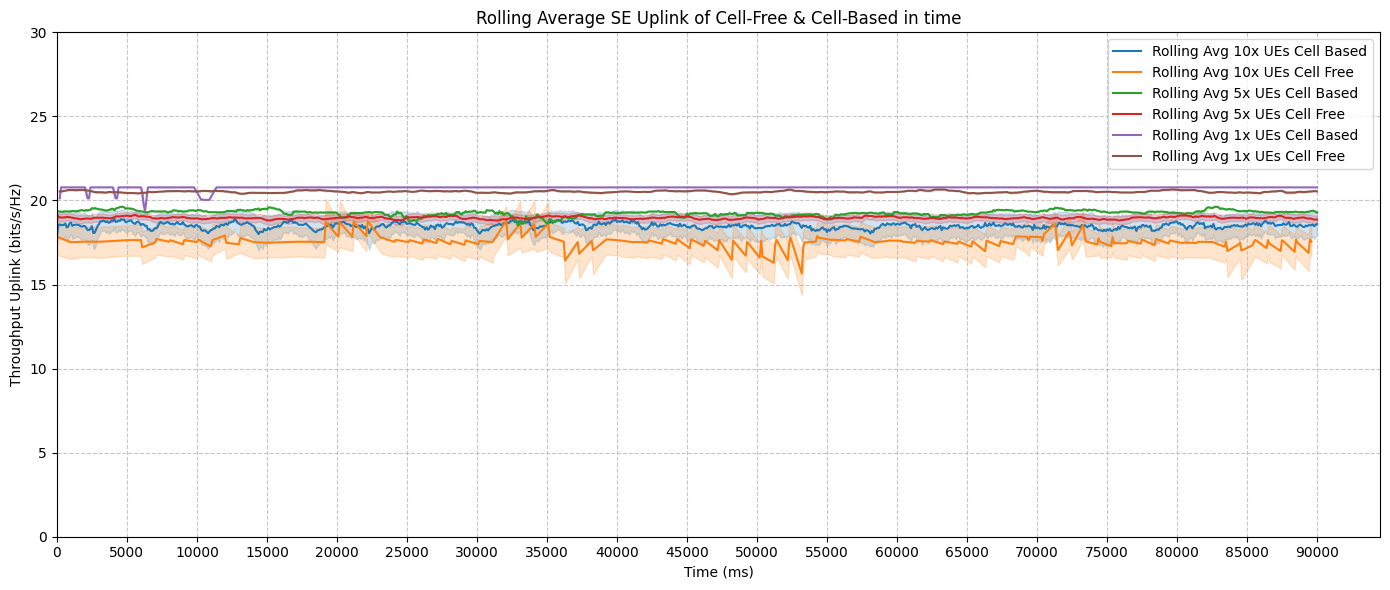

In [20]:
# Round of throughput values to 3 decimal places
df_cb_1["Mean_UL_SE_bit_per_s_Hz"] = df_cb_1["Mean_UL_SE_bit_per_s_Hz"].round(3)
df_cb_1["Rolling Avg (bits/s/Hz)"] = df_cb_1["Mean_UL_SE_bit_per_s_Hz"].rolling(window=5).mean()
df_cf_1["Mean_UL_SE_bit_per_s_Hz"] = df_cf_1["Mean_UL_SE_bit_per_s_Hz"].round(3)
df_cf_1["Rolling Avg (bits/s/Hz)"] = df_cf_1["Mean_UL_SE_bit_per_s_Hz"].rolling(window=5).mean()

# Round of throughput values to 3 decimal places
df_cb_5["Mean_UL_SE_bit_per_s_Hz"] = df_cb_5["Mean_UL_SE_bit_per_s_Hz"].round(3)
df_cb_5["Rolling Avg (bits/s/Hz)"] = df_cb_5["Mean_UL_SE_bit_per_s_Hz"].rolling(window=5).mean()
df_cf_5["Mean_UL_SE_bit_per_s_Hz"] = df_cf_5["Mean_UL_SE_bit_per_s_Hz"].round(3)
df_cf_5["Rolling Avg (bits/s/Hz)"] = df_cf_5["Mean_UL_SE_bit_per_s_Hz"].rolling(window=5).mean()

# Round of throughput values to 3 decimal places
df_cb_10["Mean_UL_SE_bit_per_s_Hz"] = df_cb_10["Mean_UL_SE_bit_per_s_Hz"].round(3)
df_cb_10["Rolling Avg (bits/s/Hz)"] = df_cb_10["Mean_UL_SE_bit_per_s_Hz"].rolling(window=5).mean()
df_cf_10["Mean_UL_SE_bit_per_s_Hz"] = df_cf_10["Mean_UL_SE_bit_per_s_Hz"].round(3)
df_cf_10["Rolling Avg (bits/s/Hz)"] = df_cf_10["Mean_UL_SE_bit_per_s_Hz"].rolling(window=5).mean()

# Graphic of Throughput and Rolling Average
plt.figure(figsize=(14, 6))
sns.lineplot(x="Time_ms", y="Rolling Avg (bits/s/Hz)", data=df_cb_10, label="Rolling Avg 10x UEs Cell Based")
sns.lineplot(x="Time_ms", y="Rolling Avg (bits/s/Hz)", data=df_cf_10, label="Rolling Avg 10x UEs Cell Free")
sns.lineplot(x="Time_ms", y="Rolling Avg (bits/s/Hz)", data=df_cb_5, label="Rolling Avg 5x UEs Cell Based")
sns.lineplot(x="Time_ms", y="Rolling Avg (bits/s/Hz)", data=df_cf_5, label="Rolling Avg 5x UEs Cell Free")
sns.lineplot(x="Time_ms", y="Rolling Avg (bits/s/Hz)", data=df_cb_1, label="Rolling Avg 1x UEs Cell Based")
sns.lineplot(x="Time_ms", y="Rolling Avg (bits/s/Hz)", data=df_cf_1, label="Rolling Avg 1x UEs Cell Free")
plt.title("Rolling Average SE Uplink of Cell-Free & Cell-Based in time")
plt.xlabel("Time (ms)")
plt.ylabel("Throughput Uplink (bits/s/Hz)")
plt.legend()

plt.grid(True)
plt.ylim(0, 30)
plt.xlim(left=0)
plt.gca().xaxis.set_major_locator(MultipleLocator(5000))
plt.grid(True, linestyle='--', alpha=0.7)
plt.tight_layout()
plt.show()

## Boxplots avg se

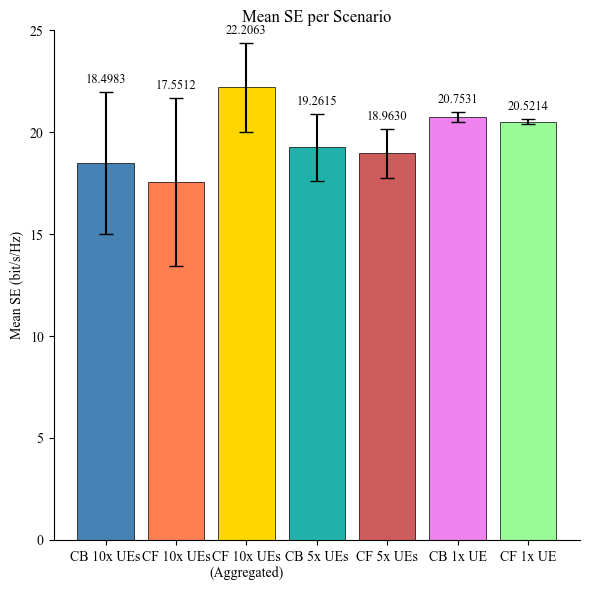

In [74]:

plt.rcParams["font.family"] = "Times New Roman"

# Médias
mean_se_total_1 = df_cb_10['Mean_UL_SE_bit_per_s_Hz'].mean()
mean_se_total_2 = df_cb_5['Mean_UL_SE_bit_per_s_Hz'].mean()
mean_se_total_3 = df_cb_1['Mean_UL_SE_bit_per_s_Hz'].mean()
mean_se_total_4 = df_cf_10['Mean_UL_SE_bit_per_s_Hz'].mean()
mean_se_total_41 = dfs_cf_10_aggr['SE_total_bit_per_s_Hz'].mean()
mean_se_total_5 = df_cf_5['Mean_UL_SE_bit_per_s_Hz'].mean()
mean_se_total_6 = df_cf_1['Mean_UL_SE_bit_per_s_Hz'].mean()

# Desvios padrão
std_se_total_1 = df_cb_10['Mean_UL_SE_bit_per_s_Hz'].std()
std_se_total_2 = df_cb_5['Mean_UL_SE_bit_per_s_Hz'].std()
std_se_total_3 = df_cb_1['Mean_UL_SE_bit_per_s_Hz'].std()
std_se_total_4 = df_cf_10['Mean_UL_SE_bit_per_s_Hz'].std()
std_se_total_41 = dfs_cf_10_aggr['SE_total_bit_per_s_Hz'].std()
std_se_total_5 = df_cf_5['Mean_UL_SE_bit_per_s_Hz'].std()
std_se_total_6 = df_cf_1['Mean_UL_SE_bit_per_s_Hz'].std()

# Lista de valores
mean_values = [
    mean_se_total_1,
    mean_se_total_4,
    mean_se_total_41,
    mean_se_total_2,
    mean_se_total_5,
    mean_se_total_3,
    mean_se_total_6
]

std_values = [
    std_se_total_1,
    std_se_total_4,
    std_se_total_41,
    std_se_total_2,
    std_se_total_5,
    std_se_total_3,
    std_se_total_6
]

labels = [
    "CB 10x UEs",
    "CF 10x UEs",
    "CF 10x UEs\n(Aggregated)",
    "CB 5x UEs",
    "CF 5x UEs",
    "CB 1x UE",
    "CF 1x UE"
]

colors = ["steelblue", "coral", "gold", "lightseagreen",
          "indianred", "violet", "palegreen"]

plt.figure(figsize=(6, 6))
bars = plt.bar(labels, mean_values, color=colors, yerr=std_values, capsize=5,
               edgecolor="black", linewidth=0.5)
plt.title("Mean SE per Scenario")
plt.ylabel("Mean SE (bit/s/Hz)")
plt.ylim(0, 25)
ax = plt.gca()
ax.spines['top'].set_visible(False)
ax.spines['right'].set_visible(False)
plt.grid(axis='y')
plt.grid(False)

# Anota os valores médios em cima da barra
for i, bar in enumerate(bars):
    yval = bar.get_height()
    plt.text(bar.get_x() + bar.get_width()/2, yval + std_values[i] + 0.3,
             f"{mean_values[i]:.4f}", ha='center', va='bottom', fontsize=9)

plt.tight_layout()
plt.show()

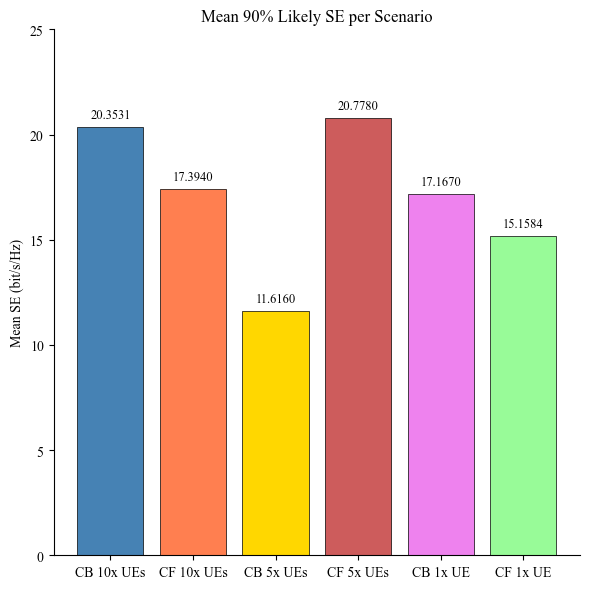

In [40]:

plt.rcParams["font.family"] = "Times New Roman"

# quantis
p10_cf_1 = df_cf_1['Mean_UL_SE_bit_per_s_Hz'].quantile(0.10)
p10_cf_5 = df_cf_5['Mean_UL_SE_bit_per_s_Hz'].quantile(0.10)
p10_cf_10 = df_cf_10['Mean_UL_SE_bit_per_s_Hz'].quantile(0.10)
p10_cb_1 = df_cb_1['Mean_UL_SE_bit_per_s_Hz'].quantile(0.10)
p10_cb_5 = df_cb_5['Mean_UL_SE_bit_per_s_Hz'].quantile(0.10)
p10_cb_10 = df_cb_10['Mean_UL_SE_bit_per_s_Hz'].quantile(0.10)

# Lista de valores
mean_values = [
    p10_cf_1,
    p10_cf_5,
    p10_cf_10,
    p10_cb_1,
    p10_cb_5,
    p10_cb_10
]

labels = [
    "CB 10x UEs",
    "CF 10x UEs",
    "CB 5x UEs",
    "CF 5x UEs",
    "CB 1x UE",
    "CF 1x UE"
]

colors = ["steelblue", "coral", "gold",
          "indianred", "violet", "palegreen"]

plt.figure(figsize=(6, 6))
bars = plt.bar(labels, mean_values, color=colors, capsize=5,
               edgecolor="black", linewidth=0.5)
plt.title("Mean 90% Likely SE per Scenario")
plt.ylabel("Mean SE (bit/s/Hz)")
plt.ylim(0, 25)
ax = plt.gca()
ax.spines['top'].set_visible(False)
ax.spines['right'].set_visible(False)
plt.grid(axis='y')
plt.grid(False)

# Anota os valores médios em cima da barra
for i, bar in enumerate(bars):
    yval = bar.get_height()
    plt.text(bar.get_x() + bar.get_width()/2, yval + 0.3,
             f"{mean_values[i]:.4f}", ha='center', va='bottom', fontsize=9)

plt.tight_layout()
plt.show()

## Stats

## Mean SE Uplink (Mbps)

| Métrica      | CB (1x UEs) | CF (1x UEs) | CB (5x UEs) | CF (5x UEs) | CB (10x UEs) | CF (10x UEs) |
|--------------|-----------|-----------|-------------|-------------|--------------|--------------|
| Count        | 907       | 910       | 4650        | 4655        | 9305         | 9100         |
| Mean         | 1.191     | 1.067     | 1.070       | 1.068       | 0.695        | 1.073        |
| Std          | 0.445     | 0.053     | 0.234       | 0.128       | 0.238        | 0.137        |
| Min          | 0.000     | 0.839     | 0.391       | 0.000       | 0.127        | 0.000        |
| 25%          | 1.036     | 1.033     | 0.982       | 0.998       | 0.560        | 0.988        |
| 50% (Median) | 1.073     | 1.068     | 1.061       | 1.066       | 0.795        | 1.071        |
| 75%          | 1.129     | 1.102     | 1.139       | 1.137       | 0.858        | 1.158        |
| Max          | 5.880     | 1.308     | 2.586       | 2.154       | 1.351        | 2.623        |


## Requirements

|                | VM RAN    | VM CN     | VM UEs      |  VM FlexRIC | 
|--------------  |-----------|-----------|-------------|-------------|
| CPU            | 12        | 2         | 14          | 4           | 
| RAM (GiB)      | 24        | 2         | 20          | 6           | 
| Storage  (GiB) | 76        | 25        | 50          | 50          | 
